# Explore road data

In [1]:
import numpy as np
import pandas as pd

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

import rasterio
from rasterio.merge import merge
from rasterio.mask import mask

import osmnx as ox

In [2]:
road_data_path = Path("../data/output/processed_roads_official/merged_osm_heigit_liu.gpkg")
roads_gdf = gpd.read_file(road_data_path)

roads_gdf.head()

c:\Users\Move\anaconda3\envs\gds24\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 207452 in column osm_changeset_timestamp, 2023-09-01T21:14:24+02:00, successfully parsed
  return ogr_read(


,ID,Start_pt,End_pt,Rd_length,Surface,data_src,continent,country_iso_a2,country_iso_a3,urban,...,lanes,oneway,bridge,layer,source,name:fr,name_en,name_fr,path,geometry
0,1.0,"(1103991.702615, 328198.947937)","(1103520.286835, 328787.695206)",762.730176,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1103991.703 328198.948, 1103..."
1,2.0,"(1103520.286835, 328787.695206)","(1103479.510506, 327812.637704)",980.028403,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1103520.287 328787.695, 1103..."
2,3.0,"(1094496.606460, 264352.420784)","(1094836.587317, 264478.208504)",364.363710,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1094496.606 264352.421, 1094..."
3,4.0,"(1102316.032584, 283330.554237)","(1101453.228606, 267250.567070)",23257.130654,unpaved,liu,None,None,None,NaN,...,None,None,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1102316.033 283330.554, 1102..."
4,5.0,"(1103057.420392, 327326.354672)","(1102985.552529, 327212.146541)",134.938827,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,"MULTILINESTRING ((1103057.42 327326.355, 11029..."


In [3]:
roads_gdf.shape

(855743, 38)

In [4]:
roads_gdf.data_src.value_counts()

data_src
heigit    355143
osm       293149
liu       207451
Name: count, dtype: int64

In [5]:
# check duplicates
roads_gdf.duplicated(subset=["geometry"]).sum()

69644

Duplicate rows (including both/all occurrences): 133800
Duplicate geometries (unique): 64156


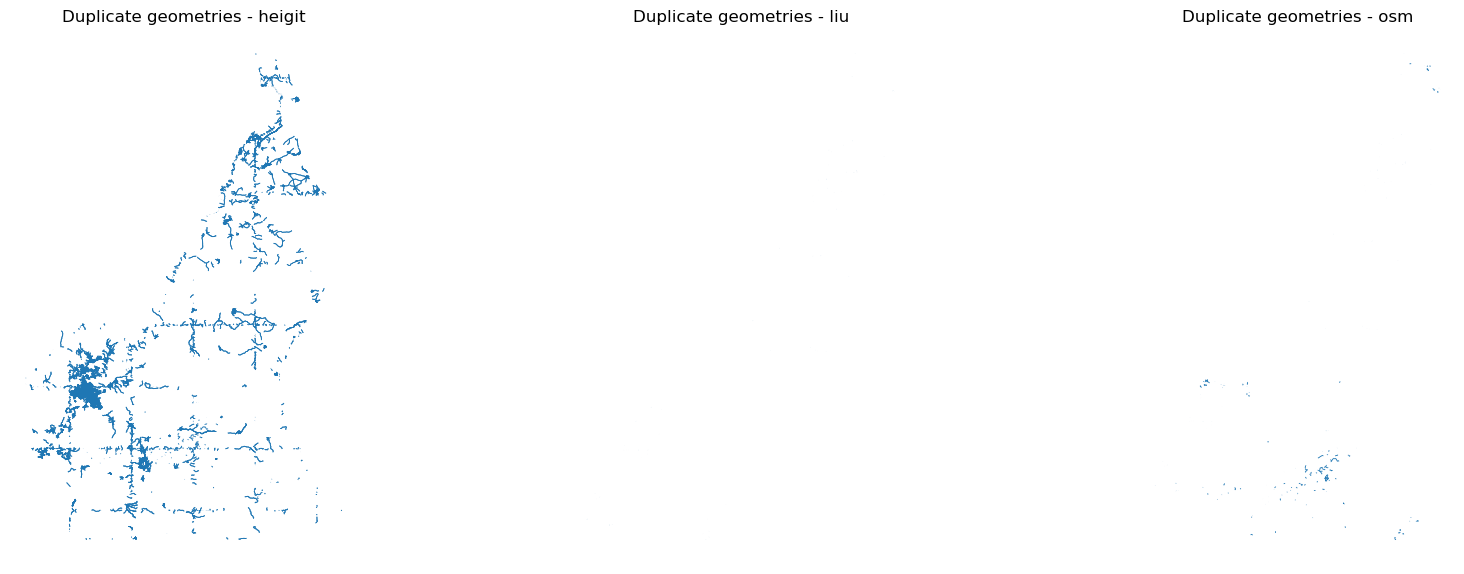

In [6]:
# Select all rows involved in duplicate geometries
dup_mask = roads_gdf.duplicated(subset=["geometry"], keep=False) # keep=False marks all duplicates as True, not just the first occurrence
duplicates_gdf = roads_gdf.loc[dup_mask].copy()

print(f"Duplicate rows (including both/all occurrences): {len(duplicates_gdf)}")
print(f"Duplicate geometries (unique): {duplicates_gdf['geometry'].nunique()}")

# Plot 3 separate maps by data source
if duplicates_gdf.empty:
    print("No duplicate geometries found.")
else:
    sources = sorted(duplicates_gdf["data_src"].dropna().unique())[:3]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, ax in enumerate(axes):
        if i < len(sources):
            src = sources[i]
            duplicates_gdf.loc[duplicates_gdf["data_src"] == src].plot(
                ax=ax, linewidth=0.6
            )
            ax.set_title(f"Duplicate geometries - {src}")
        else:
            ax.set_title("No data")
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

In [7]:
duplicates_gdf.data_src.value_counts()

data_src
heigit    133435
osm          300
liu           65
Name: count, dtype: int64

In [8]:
dup_counts = duplicates_gdf["geometry"].value_counts()
num_duplicate_pairs = (dup_counts // 2).sum()

print(f"Number of duplicate pairs: {num_duplicate_pairs}")

Number of duplicate pairs: 66448


In [9]:
dup_counts

geometry
MULTILINESTRING ((1548646.254 1254030.073, 154...    36
MULTILINESTRING ((1574924.222 1260204.201, 157...    20
MULTILINESTRING ((1145146.719 625825.402, 1145...    16
MULTILINESTRING ((1092958.806 445767.547, 1093...    16
MULTILINESTRING ((1192410.637 625644.42, 11924...    16
                                                     ..
MULTILINESTRING ((1140956.208 672303.797, 1141...     2
MULTILINESTRING ((1139578.406 671890.857, 1139...     2
MULTILINESTRING ((1139628.946 672244.805, 1139...     2
MULTILINESTRING ((1139588.871 672118.315, 1139...     2
MULTILINESTRING ((1154458.294 694190.637, 1154...     2
Name: count, Length: 64156, dtype: int64

In [10]:
# create a new GeoDataFrame by dropping duplicates based on geometry, keeping the first occurrence
roads_gdf_dedup = roads_gdf.drop_duplicates(subset=["geometry"], keep="first").copy()
print(f"Number of rows after deduplication: {len(roads_gdf_dedup)}")

Number of rows after deduplication: 786099


In [11]:
# Deduplicate by osm_id only for non-liu rows
liu_mask = roads_gdf_dedup["data_src"].eq("liu")
non_liu = roads_gdf_dedup.loc[~liu_mask]
non_liu_dedup = pd.concat(
    [
        non_liu.loc[non_liu["osm_id"].isna()],  # keep rows without osm_id
        non_liu.loc[non_liu["osm_id"].notna()].drop_duplicates(subset=["osm_id"], keep="first"),
    ]
)

roads_gdf_dedup = pd.concat([roads_gdf_dedup.loc[liu_mask], non_liu_dedup]).sort_index().copy()
print(f"Number of rows after deduplication: {len(roads_gdf_dedup)}")

Number of rows after deduplication: 533153


In [12]:
roads_gdf_dedup.data_src.value_counts()

data_src
heigit    285769
liu       207451
osm        39933
Name: count, dtype: int64

In [13]:
# create a new column 'liu_surface' by copying the 'surface' value for rows where 'data_src' is 'liu', and 'unpaved' for all other rows
roads_gdf_dedup["liu_surface"] = np.where(roads_gdf_dedup["data_src"] == "liu", roads_gdf_dedup["Surface"], "unpaved")
roads_gdf_dedup["liu_surface"].value_counts()

liu_surface
unpaved    512943
paved       20210
Name: count, dtype: int64

In [15]:
# remove any vectors that are overlapping in terms of location with the 'liu' data source
liu_gdf = roads_gdf_dedup.loc[roads_gdf_dedup["data_src"] == "liu"].copy()
non_liu_gdf = roads_gdf_dedup.loc[roads_gdf_dedup["data_src"] != "liu"].copy()

# Ensure both GeoDataFrames use the same CRS
liu_gdf = liu_gdf.to_crs(non_liu_gdf.crs)

# Add an index to liu_gdf for identification
liu_gdf = liu_gdf.reset_index(drop=True)
liu_gdf["liu_idx"] = liu_gdf.index

# Perform a spatial join: find non_liu_gdf rows that intersect any liu_gdf row
joined = gpd.sjoin(non_liu_gdf, liu_gdf[["geometry", "liu_idx"]], how="left", predicate="intersects")

# Rows with a match in liu_gdf will have a non-null 'liu_idx'
non_liu_no_overlap = joined[joined["liu_idx"].isna()].drop(columns=["liu_idx", "index_right"])

# Concatenate liu_gdf and the filtered non_liu_gdf
final_gdf = pd.concat([liu_gdf, non_liu_no_overlap]).sort_index().copy()
print(f"Number of rows after removing overlaps: {len(final_gdf)}")
final_gdf.data_src.value_counts()

Number of rows after removing overlaps: 304351


data_src
liu       207451
heigit     76222
osm        20678
Name: count, dtype: int64

# save gdf

In [17]:
# save the deduplicated GeoDataFrame to a new file
final_path = Path("../data/output/processed_roads_official/cleaned_merged_osm_heigit_liu.gpkg")
final_gdf.to_file(final_path, driver="GPKG")

# load cleaned roads

In [2]:
# load the saved file to verify
filepath = Path("../data/output/processed_roads_official/cleaned_merged_osm_heigit_liu.gpkg")
loaded_gdf = gpd.read_file(filepath)
loaded_gdf.head()

,ID,Start_pt,End_pt,Rd_length,Surface,data_src,continent,country_iso_a2,country_iso_a3,urban,...,bridge,layer,source,name:fr,name_en,name_fr,path,liu_surface,liu_idx,geometry
0,1.0,"(1103991.702615, 328198.947937)","(1103520.286835, 328787.695206)",762.730176,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,paved,0.0,"MULTILINESTRING ((1103991.703 328198.948, 1103..."
1,2.0,"(1103520.286835, 328787.695206)","(1103479.510506, 327812.637704)",980.028403,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,paved,1.0,"MULTILINESTRING ((1103520.287 328787.695, 1103..."
2,3.0,"(1094496.606460, 264352.420784)","(1094836.587317, 264478.208504)",364.363710,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,paved,2.0,"MULTILINESTRING ((1094496.606 264352.421, 1094..."
3,4.0,"(1102316.032584, 283330.554237)","(1101453.228606, 267250.567070)",23257.130654,unpaved,liu,None,None,None,NaN,...,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,unpaved,3.0,"MULTILINESTRING ((1102316.033 283330.554, 1102..."
4,5.0,"(1103057.420392, 327326.354672)","(1102985.552529, 327212.146541)",134.938827,paved,liu,None,None,None,NaN,...,None,None,None,None,None,None,D:/GitHub/_epa_thesis/strategic-road-planning/...,paved,4.0,"MULTILINESTRING ((1103057.42 327326.355, 11029..."


In [4]:
# calculate the total length of roads in the final GeoDataFrame
gdf = loaded_gdf.to_crs(32632)  # example projected CRS in meters; pick one suitable for your area

# length of each road segment (meters)
gdf["length_m"] = gdf.geometry.length

# total length in km
total_km = gdf["length_m"].sum() / 1000
print(total_km)

208196.10649924283


In [5]:
# calculate total length of paved vs unpaved roads
paved_length_km = gdf.loc[gdf["liu_surface"] == "paved", "length_m"].sum() / 1000
unpaved_length_km = gdf.loc[gdf["liu_surface"] == "unpaved", "length_m"].sum() / 1000
print(f"Paved roads: {paved_length_km:.2f} km")
print(f"Unpaved roads: {unpaved_length_km:.2f} km")

Paved roads: 17297.43 km
Unpaved roads: 190898.68 km


In [12]:
print(f"Percentage of paved roads: {(paved_length_km/total_km)*100:.2f}%")
print(f"Percentage of unpaved roads: {(unpaved_length_km/total_km)*100:.2f}%")

Percentage of paved roads: 8.31%
Percentage of unpaved roads: 91.69%


In [13]:
from pyproj import Geod

# WGS84 ellipsoid
geod = Geod(ellps="WGS84")

def geodesic_length(geom):
    # Only compute for LineString or MultiLineString
    if geom.is_empty:
        return 0
    if geom.geom_type == "LineString":
        return geod.geometry_length(geom)
    elif geom.geom_type == "MultiLineString":
        return sum(geod.geometry_length(part) for part in geom.geoms)
    else:
        return 0

gdf_wgs84 = loaded_gdf.to_crs(4326)
gdf_wgs84["length_m_geodesic"] = gdf_wgs84.geometry.apply(geodesic_length)
total_km_geodesic = gdf_wgs84["length_m_geodesic"].sum() / 1000
print(f"Total geodesic road length: {total_km_geodesic:.2f} km")

Total geodesic road length: 207782.32 km


In [17]:
# do geodesic for paved vs unpaved
paved_length_km_geodesic = gdf_wgs84.loc[gdf_wgs84["liu_surface"] == "paved", "length_m_geodesic"].sum() / 1000
unpaved_length_km_geodesic = gdf_wgs84.loc[gdf_wgs84["liu_surface"] == "unpaved", "length_m_geodesic"].sum() / 1000
print(f"Paved roads (geodesic): {paved_length_km_geodesic:.2f} km")
print(f"Paved percentage (geodesic): {(paved_length_km_geodesic/total_km_geodesic)*100:.2f}%")
print(f"Unpaved roads (geodesic): {unpaved_length_km_geodesic:.2f} km")

Paved roads (geodesic): 17270.50 km
Paved percentage (geodesic): 8.31%
Unpaved roads (geodesic): 190511.82 km


In [16]:
paved_length_km_geodesic + unpaved_length_km_geodesic

207782.32241767185